## 2. You can find a dataset recording a variety of properties of secondary school students in Portugal [here](http://archive.ics.uci.edu/ml/datasets/STUDENT+ALCOHOL+CONSUMPTION). This dataset was collected by P. Cortez and A. Silva, and is hosted by the UC Irvine Machine Learning Repository. There are two datasets; one for students in a math course, and another for students in a Portuguese language course.

### (a) Use plots of conditional histograms to investigate whether math students drink more alcohol during the week than Portuguese language students.

In [32]:
from pandas import concat, read_csv, get_dummies
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt


In [2]:

from pandas import DataFrame


math = read_csv("math-students.csv", sep=";")
math["student_type"] = "math"
portuguese = read_csv("portuguese-students.csv", sep=";")
portuguese["student_type"] = "portuguese"
df: DataFrame = concat([math, portuguese])
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'student_type'],
      dtype='object')

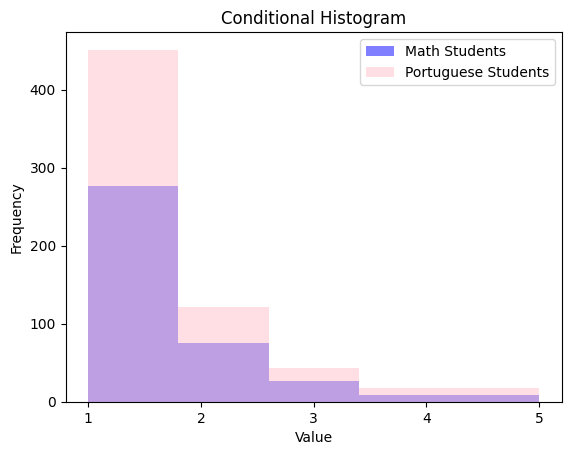

In [3]:
plt.hist(math.Dalc, label="Math Students", alpha=0.5, bins=5, color="blue")
plt.hist(portuguese.Dalc, label="Portuguese Students", alpha=0.5, bins=5, color="pink")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.xticks([1,2,3,4,5])
plt.title("Conditional Histogram")
plt.legend()
plt.savefig("conditional-histogram-transparent.png")
plt.show()

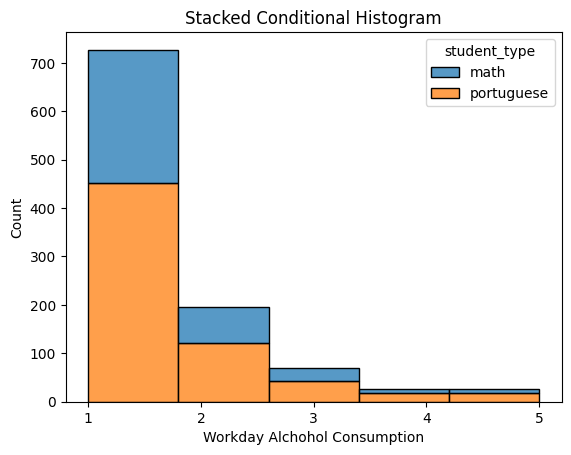

In [4]:
sns.histplot(df, x="Dalc", hue="student_type", multiple="stack", bins=5)
plt.title("Stacked Conditional Histogram")
plt.xticks([1,2,3,4,5])
plt.xlabel("Workday Alchohol Consumption")
plt.savefig("conditional-histogram-stacked.png", dpi=300, bbox_inches='tight')
plt.show()


In [5]:
print(round(math.Dalc.mean(), 2))
print(round(portuguese.Dalc.mean(), 2))

1.48
1.5


### (b) Use plots of conditional histograms to investigate whether students from small families drink more alcohol at the weekend than those from large families.

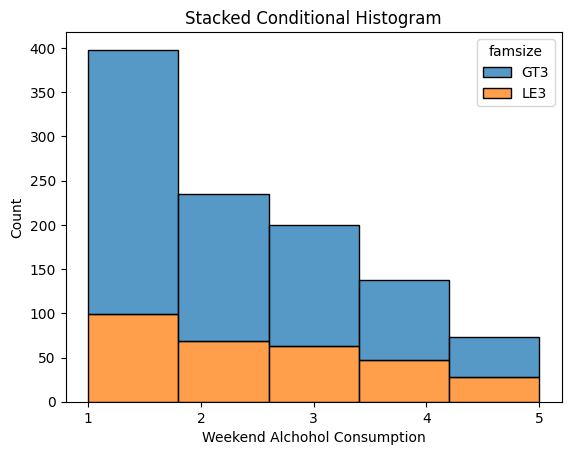

In [6]:
# df["famsize"] = df["famsize"].replace({"GT3": "4 Or More", "LE3": "3 Or Less"})
sns.histplot(df, x="Walc", hue="famsize", multiple="stack", bins=5)
plt.title("Stacked Conditional Histogram")
plt.xticks([1,2,3,4,5])
plt.xlabel("Weekend Alchohol Consumption")
plt.savefig("family-size-alchohol.png", dpi=300, bbox_inches='tight')
plt.show()


In [7]:
print(round(df[df["famsize"] == "GT3"].Walc.mean(), 2))
print(round(df[df["famsize"] == "LE3"].Walc.mean(), 2))

2.21
2.46


### (c) Each of the variables school, sex, famsize and romantic has two possible values. This means that if we characterize students by the values of these variables, there are sixteen possible types of student. Use box plots to investigate which of these types drinks more alcohol in total.

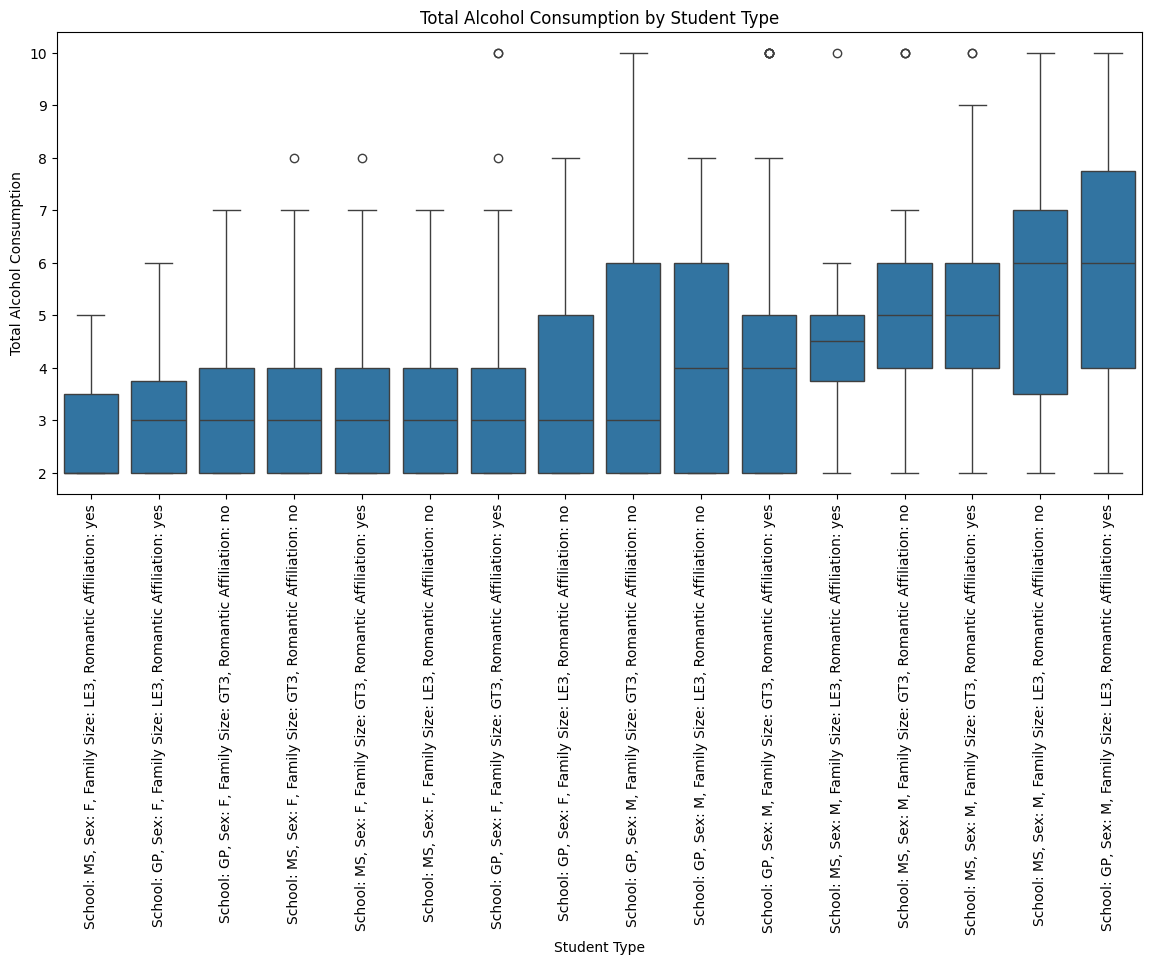

In [8]:
df['student_type'] = "School: " + df['school'] + ', ' + "Sex: " + df['sex'] + ', ' + "Family Size: " + df['famsize'] + ', ' + "Romantic Affiliation: " + df['romantic']
df['Total_Alcohol'] = df['Dalc'] + df['Walc']
student_type_order = df.groupby('student_type')['Total_Alcohol'].mean().sort_values().index
plt.figure(figsize=(14, 6))
sns.boxplot(x='student_type', y='Total_Alcohol', data=df, order=student_type_order)
plt.xticks(rotation=90)
plt.xlabel("Student Type")
plt.ylabel("Total Alcohol Consumption")
plt.title("Total Alcohol Consumption by Student Type")
plt.savefig("boxplot.png")
plt.show()

## 1.15 You can find a dataset recording some properties of Taiwanese credit card holders at http://archive.ics.uci.edu/ml/ datasets/default+of+credit+card+clients. This dataset was collected by I-Cheng Yeh, and is hosted by the UC Irvine Machine Learning Repository. There is a variable indicating whether a holder defaulted or not, and a variety of other variables.

In [14]:
df = read_csv("credit-card-data.csv")
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

### (a) Use plots of conditional histograms to investigate whether people who default have more debt (use the variable X1 for debt) than those who don’t default.

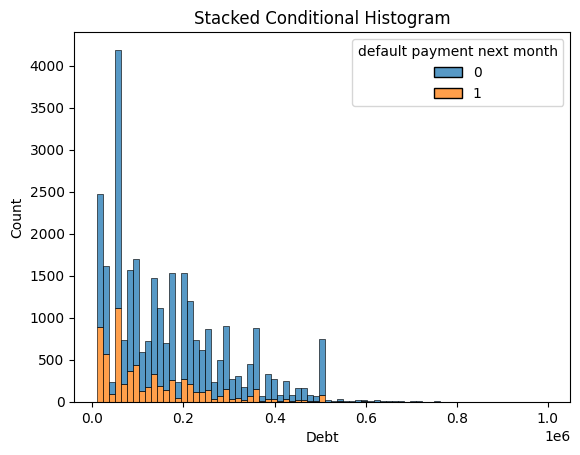

In [22]:
# df["famsize"] = df["famsize"].replace({"GT3": "4 Or More", "LE3": "3 Or Less"})


sns.histplot(df, x="LIMIT_BAL", hue="default payment next month", multiple="stack", bins = 75)
plt.title("Stacked Conditional Histogram")
plt.xlabel("Debt")
plt.savefig("debt-default.png", dpi=300, bbox_inches='tight')
plt.show()

In [24]:
print(round(df[df["default payment next month"] == 0].LIMIT_BAL.mean(), 2))
print(round(df[df["default payment next month"] == 1].LIMIT_BAL.mean(), 2))

178099.73
130109.66


### (b) Use box plots to investigate whether gender, education or marital status has any effect on the amount of debt (again, use X1 for debt).

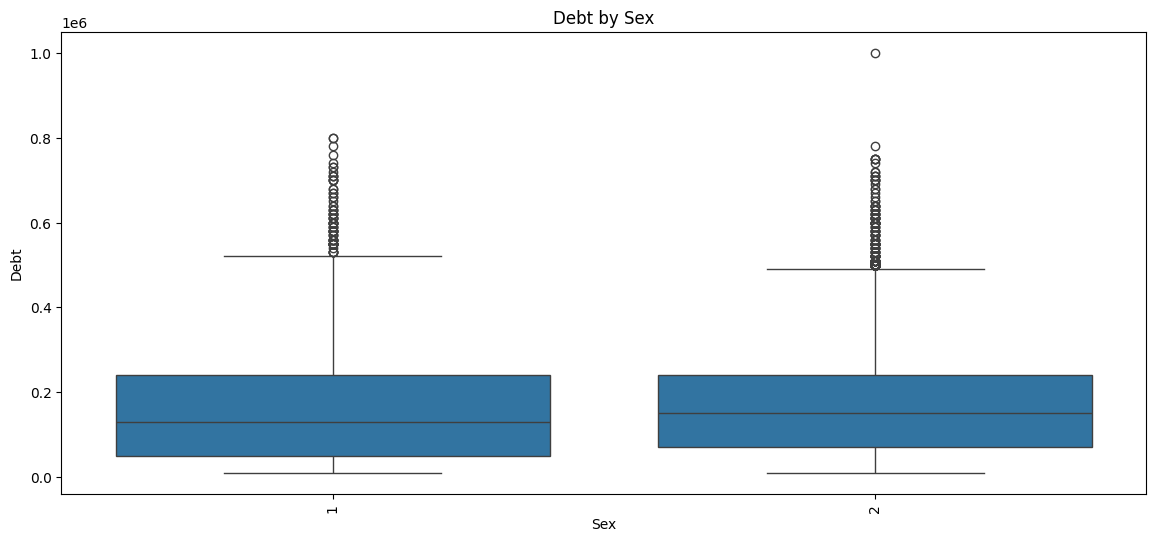

In [40]:
student_type_order = df.groupby('SEX')['LIMIT_BAL'].mean().index
plt.figure(figsize=(14, 6))
sns.boxplot(x='SEX', y='LIMIT_BAL', data=df, order=student_type_order)
plt.xticks(rotation=90)
plt.xlabel("Sex")
plt.ylabel("Debt")
plt.title("Debt by Sex")
plt.savefig("boxplot2.png")
plt.show()

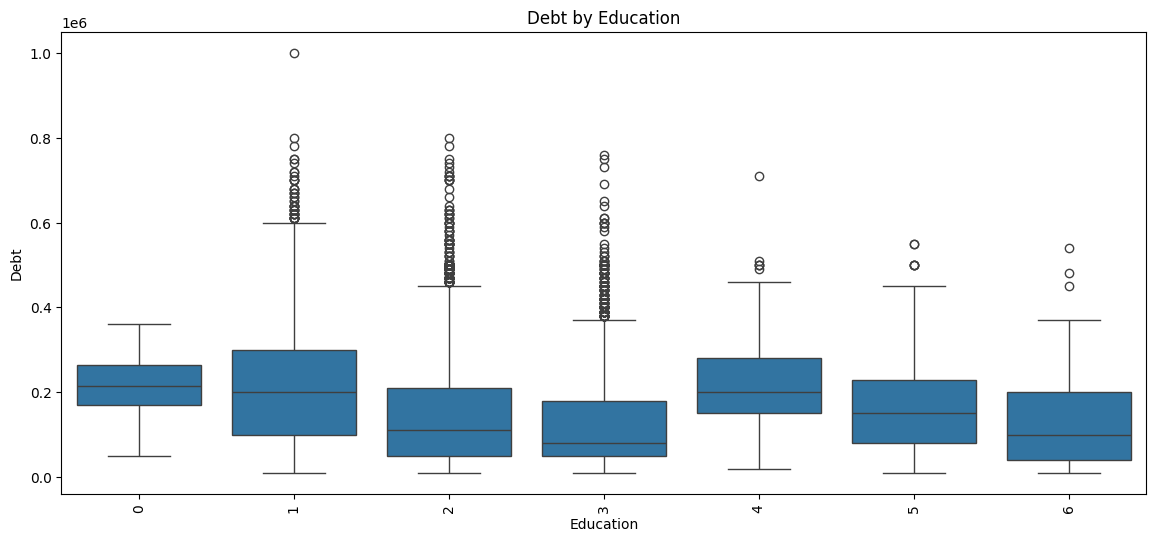

In [41]:
student_type_order = df.groupby('EDUCATION')['LIMIT_BAL'].mean().index
plt.figure(figsize=(14, 6))
sns.boxplot(x='EDUCATION', y='LIMIT_BAL', data=df, order=student_type_order)
plt.xticks(rotation=90)
plt.xlabel("Education")
plt.ylabel("Debt")
plt.title("Debt by Education")
plt.savefig("boxplot3.png")
plt.show()

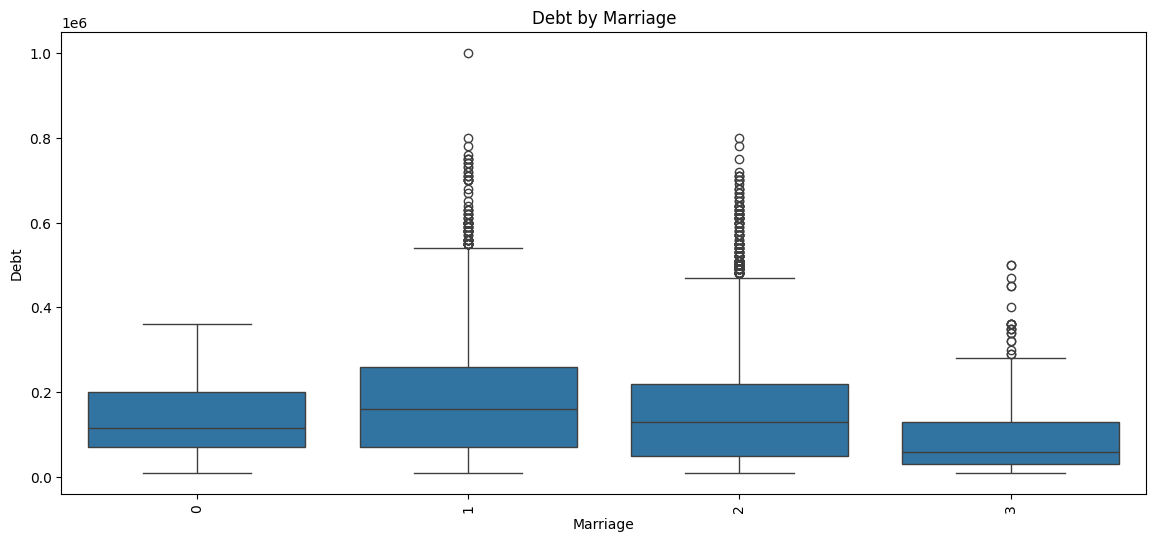

In [42]:
student_type_order = df.groupby('MARRIAGE')['LIMIT_BAL'].mean().index
plt.figure(figsize=(14, 6))
sns.boxplot(x='MARRIAGE', y='LIMIT_BAL', data=df, order=student_type_order)
plt.xticks(rotation=90)
plt.xlabel("Marriage")
plt.ylabel("Debt")
plt.title("Debt by Marriage")
plt.savefig("boxplot4.png")
plt.show()

In [36]:
get_dummies(df[["SEX", "EDUCATION", "MARRIAGE", "LIMIT_BAL"]]).corr()["LIMIT_BAL"][[]]

SEX          0.024755
EDUCATION   -0.219161
MARRIAGE    -0.108139
LIMIT_BAL    1.000000
Name: LIMIT_BAL, dtype: float64